In [3]:
import numpy as np
import cv2

from PIL import Image
import os
import glob

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


In [4]:
path_to_zip = '/kaggle/input/alzheimer1'
data_dir = os.path.join(path_to_zip, 'diseases')

In [5]:
data_dir

'/kaggle/input/alzheimer1/diseases'

In [6]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('/kaggle/input/alzheimer1/diseases')

In [7]:
list(data_dir.glob('*/*.png'))[:5]

[PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI128_S_1148a099.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI027_S_1277a078.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI023_S_1104a105.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI067_S_0607b096.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI116_S_0752a119.png')]

In [8]:
image_count = len(list(data_dir.glob('*/*.png')))
print(image_count)

5154


In [9]:
AD = list(data_dir.glob('AD/*'))
AD[:5]

[PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD136_S_0426a120.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD136_S_0299a094.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD007_S_1304a100.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD136_S_0299b094.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD023_S_1262b106.png')]

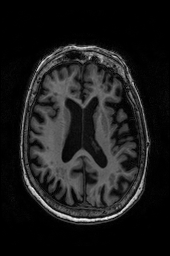

In [10]:
# PIL.Image.open(str(roses[1]))

from PIL import Image
im = Image.open(str(AD[1]))
im

In [11]:
CI = list(data_dir.glob('CI/*'))
CI[:5]

[PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI128_S_1148a099.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI027_S_1277a078.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI023_S_1104a105.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI067_S_0607b096.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/CI/CI116_S_0752a119.png')]

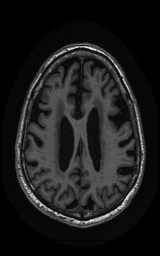

In [12]:
im = Image.open(str(CI[1]))
im

In [13]:
disease_images_dict = {
    'AD': list(data_dir.glob('AD/*')),
    'CI': list(data_dir.glob('CI/*')),
    'CN': list(data_dir.glob('CN/*')),
}

In [14]:
disease_labels_dict = {
    'AD': 0,
    'CI': 1,
    'CN': 2,
}

In [15]:
disease_images_dict['AD'][:5]

[PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD136_S_0426a120.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD136_S_0299a094.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD007_S_1304a100.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD136_S_0299b094.png'),
 PosixPath('/kaggle/input/alzheimer1/diseases/AD/AD023_S_1262b106.png')]

In [16]:
str(disease_images_dict['AD'][0])

'/kaggle/input/alzheimer1/diseases/AD/AD136_S_0426a120.png'

In [17]:
img = cv2.imread(str(disease_images_dict['AD'][0]))

In [18]:
img.shape

(256, 170, 3)

In [19]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [20]:
X, y = [], []

for disease_name, images in disease_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(disease_labels_dict[disease_name])

In [21]:
X = np.array(X)
y = np.array(y)

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [23]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [24]:
X[0].shape

(224, 224, 3)

In [25]:
IMAGE_SHAPE = (224, 224)

classifier = tf.keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE+(3,))
])
# "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"
# https://tfhub.dev/google/imagenet/inception_v3/classification/5

2022-05-02 06:07:49.235083: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [26]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [27]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

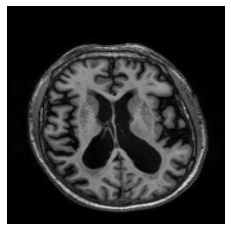

In [28]:
plt.axis('off')
plt.imshow(X[0])

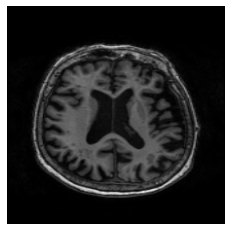

In [29]:
plt.axis('off')
plt.imshow(X[1])


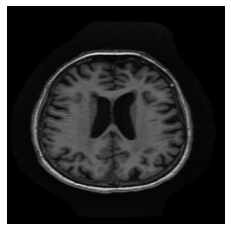

In [30]:
plt.axis('off')
plt.imshow(X[2])

In [31]:
predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted


2022-05-02 06:07:52.915191: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


array([788, 722, 620])

In [32]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)


In [33]:
num_of_diseases = 3

model = tf.keras.Sequential([
  pretrained_model_without_top_layer,
  tf.keras.layers.Dense(num_of_diseases)
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
keras_layer_1 (KerasLayer)   (None, 1280)              2257984   
_________________________________________________________________
dense (Dense)                (None, 3)                 3843      
Total params: 2,261,827
Trainable params: 3,843
Non-trainable params: 2,257,984
_________________________________________________________________


In [34]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=20)

Epoch 1/20
121/121 [==============================] - 28s 200ms/step - loss: 0.9980 - acc: 0.5195
Epoch 2/20
121/121 [==============================] - 24s 200ms/step - loss: 0.8272 - acc: 0.6230
Epoch 3/20
121/121 [==============================] - 24s 196ms/step - loss: 0.7382 - acc: 0.6968
Epoch 4/20
121/121 [==============================] - 24s 200ms/step - loss: 0.6854 - acc: 0.7273
Epoch 5/20
121/121 [==============================] - 24s 199ms/step - loss: 0.6417 - acc: 0.7472
Epoch 6/20
121/121 [==============================] - 24s 200ms/step - loss: 0.6024 - acc: 0.7731
Epoch 7/20
121/121 [==============================] - 24s 195ms/step - loss: 0.5719 - acc: 0.7876
Epoch 8/20
121/121 [==============================] - 24s 199ms/step - loss: 0.5437 - acc: 0.8000
Epoch 9/20
121/121 [==============================] - 24s 198ms/step - loss: 0.5146 - acc: 0.8202
Epoch 10/20
121/121 [==============================] - 26s 213ms/step - loss: 0.5037 - acc: 0.8269
Epoch 11/20
121/121

In [35]:
model.evaluate(X_test_scaled,y_test)

41/41 [==============================] - 9s 196ms/step - loss: 0.4155 - acc: 0.8712


[0.415546715259552, 0.8712180256843567]